In [1]:
import os
import json
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F


from generative.networks.nets import AutoencoderKL
from generative.losses import PerceptualLoss


/users/tdd540/.local/share/flight/env/conda+python_env/lib/python3.14/site-packages/generative/networks/layers/vector_quantizer.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
/users/tdd540/.local/share/flight/env/conda+python_env/lib/python3.14/site-packages/generative/networks/layers/vector_quantizer.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [3]:
with open("data_split.json", "r") as f:
    split_data = json.load(f)

train_subjects = split_data["train"]
val_subjects = split_data["validation"]
test_subjects = split_data["test"]

print("Train:", len(train_subjects))
print("Validation:", len(val_subjects))
print("Test:", len(test_subjects))


Train: 1000
Validation: 125
Test: 126


In [4]:
train_data = r"Data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"


In [5]:
def preprocess_t2f(image):
    # Expected original BraTS shape
    if image.shape != (240, 240, 155):
        raise ValueError(f"Unexpected image shape: {image.shape}")

    image = image[16:224, 8:232, :]

    image = np.pad(
        image,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    foreground = image > 0

    if not np.any(foreground):
        raise ValueError("No foreground voxels found")

    upper = np.percentile(image[foreground], 99.9)

    image = np.clip(image, 0, upper)

    image = image / upper

    image[~foreground] = 0

    return image.astype(np.float32)


In [6]:
def preprocess_mask(mask):
    # Expected original BraTS shape
    if mask.shape != (240, 240, 155):
        raise ValueError(f"Unexpected mask shape: {mask.shape}")

    # Apply exactly the same spatial crop as T2f
    mask = mask[16:224, 8:232, :]

    # Apply exactly the same z-padding as T2f
    mask = np.pad(
        mask,
        ((0, 0), (0, 0), (2, 3)),
        mode="constant",
        constant_values=0
    )

    return mask.astype(np.int64)


In [7]:
from torch.utils.data import Dataset, DataLoader

class BraTSDataset(Dataset):
    def __init__(
        self,
        subjects,
        data_dir
    ):
        self.subjects = subjects
        self.data_dir = data_dir

    def __len__(self):
        return len(
            self.subjects
        )

    def __getitem__(
        self,
        idx
    ):
        subject = self.subjects[
            idx
        ]

        subject_path = os.path.join(
            self.data_dir,
            subject
        )

        files = os.listdir(
            subject_path
        )

        t2f_file = [
            f for f in files
            if "t2f" in f.lower()
        ][0]

        seg_file = [
            f for f in files
            if "seg" in f.lower()
        ][0]

        image = nib.load(
            os.path.join(
                subject_path,
                t2f_file
            )
        ).get_fdata()

        mask = nib.load(
            os.path.join(
                subject_path,
                seg_file
            )
        ).get_fdata()

        image = preprocess_t2f(
            image
        )

        mask = preprocess_mask(
            mask
        )

        image = torch.from_numpy(
            image
        ).float().unsqueeze(
            0
        )

        mask = torch.from_numpy(
            mask
        ).long().unsqueeze(
            0
        )

        return {
            "image": image,
            "mask": mask,
            "subject": subject
        }


In [8]:
train_dataset = BraTSDataset(
    subjects=train_subjects,
    data_dir=train_data
)

print("Dataset size:", len(train_dataset))


Dataset size: 1000


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(
    "Number of training batches:",
    len(train_loader)
)


Number of training batches: 1000


In [10]:
# ============================================================
# VAE V9 — MONAI AutoencoderKL
# MONAI AutoencoderKL
# ============================================================

# NOTE:
# The official MONAI 3D LDM tutorial uses AutoencoderKL directly.
# Here we adapt its channel capacity to this project:
# 64 -> 128 -> 256, latent_channels=8.
#
# Three channel levels imply two spatial downsamples:
# 208 x 224 x 160 -> 104 x 112 x 80 -> 52 x 56 x 40 (x4).
#
# Attention/non-local attention are disabled in this VAE because
# 52 x 56 x 40 is a very large 3D latent grid and full attention
# at that resolution would be prohibitively memory-intensive.

def create_monai_vae_v9():
    return AutoencoderKL(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        num_channels=(64, 128, 256),
        latent_channels=8,
        num_res_blocks=2,
        norm_num_groups=16,
        attention_levels=(False, False, False),
        with_encoder_nonlocal_attn=False,
        with_decoder_nonlocal_attn=False,
        use_checkpointing=True,
        use_convtranspose=False,
    )


In [11]:
# ============================================================
# VAE V9 — MONAI AutoencoderKL
# MONAI-compatible VAE loss
#
# L = L1
#     + 0.1 * L_perceptual
#     + 1e-7 * L_KL
#     + tumour_weight * L_tumour
#
# KL reduction follows MONAI 3D LDM tutorial style:
# sum over latent dimensions per sample,
# then mean over batch.
# ============================================================

def vae_loss_v9_monai(
    reconstruction,
    target,
    mask,
    z_mu,
    z_sigma,
    perceptual_loss_fn,
    tumour_weight=1.0,
    perceptual_weight=0.1,
    kl_weight=1e-7,
):

    # --------------------------------
    # 1. Global L1 reconstruction
    # --------------------------------
    l1_loss = F.l1_loss(
        reconstruction,
        target
    )

    # --------------------------------
    # 2. Tumour-region L1
    # --------------------------------
    tumour_region = mask > 0

    if tumour_region.any():

        tumour_region = tumour_region.expand_as(
            reconstruction
        )

        tumour_loss = F.l1_loss(
            reconstruction[tumour_region],
            target[tumour_region]
        )

    else:

        tumour_loss = torch.zeros(
            (),
            device=target.device,
            dtype=reconstruction.dtype
        )

    # --------------------------------
    # 3. MONAI perceptual loss
    # --------------------------------
    perceptual_loss = perceptual_loss_fn(
        reconstruction.float(),
        target.float()
    )

    # --------------------------------
    # 4. KL loss
    #
    # AutoencoderKL returns:
    # z_mu    : [B, C, H, W, D]
    # z_sigma : [B, C, H, W, D]
    #
    # First sum KL over all latent
    # variables for each sample.
    # Then average over the batch.
    # --------------------------------
    sigma_sq = torch.clamp(
        z_sigma.float().pow(2),
        min=1e-12
    )

    kl_per_sample = 0.5 * torch.sum(
        z_mu.float().pow(2)
        + sigma_sq
        - torch.log(sigma_sq)
        - 1.0,
        dim=[
            1,
            2,
            3,
            4
        ]
    )

    kl_loss = kl_per_sample.mean()

    # --------------------------------
    # 5. Total VAE loss
    # --------------------------------
    total_loss = (
        l1_loss
        + perceptual_weight * perceptual_loss
        + kl_weight * kl_loss
        + tumour_weight * tumour_loss
    )

    return (
        total_loss,
        l1_loss,
        tumour_loss,
        perceptual_loss,
        kl_loss,
    )

In [12]:
# ============================================================
# VAE V9 — MONAI AutoencoderKL
# Training loop
# ============================================================

def train_vae_v9_monai(
    model,
    train_loader,
    epochs,
    optimizer,
    device,
    perceptual_loss_fn,
    checkpoint_dir="vae_x4_v9_monai_checkpoints",
    tumour_weight=1.0,
    perceptual_weight=0.1,
    kl_weight=1e-7,
):
    os.makedirs(
        checkpoint_dir,
        exist_ok=True
    )

    histories = {
        "total": [],
        "recon": [],
        "tumour": [],
        "perceptual": [],
        "kl": [],
    }

    use_amp = (
        device.type == "cuda"
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=use_amp
    )

    for epoch in range(
        epochs
    ):
        model.train()

        sums = {
            key: 0.0
            for key in histories
        }

        for batch_idx, batch in enumerate(
            train_loader
        ):
            image = batch[
                "image"
            ].to(
                device,
                non_blocking=True
            )

            mask = batch[
                "mask"
            ].to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp
            ):
                (
                    reconstruction,
                    z_mu,
                    z_sigma
                ) = model(
                    image
                )

                (
                    loss,
                    recon_loss,
                    tumour_loss,
                    perceptual_loss,
                    kl_loss,
                ) = vae_loss_v9_monai(
                    reconstruction=reconstruction,
                    target=image,
                    mask=mask,
                    z_mu=z_mu,
                    z_sigma=z_sigma,
                    perceptual_loss_fn=perceptual_loss_fn,
                    tumour_weight=tumour_weight,
                    perceptual_weight=perceptual_weight,
                    kl_weight=kl_weight,
                )

            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            values = {
                "total": loss.item(),
                "recon": recon_loss.item(),
                "tumour": tumour_loss.item(),
                "perceptual": perceptual_loss.item(),
                "kl": kl_loss.item(),
            }

            for key, value in values.items():
                sums[key] += value

            if (
                batch_idx + 1
            ) % 20 == 0:
                print(
                    f"VAE epoch {epoch + 1}/{epochs} | "
                    f"batch {batch_idx + 1}/{len(train_loader)} | "
                    f"total={loss.item():.6f} | "
                    f"L1={recon_loss.item():.6f} | "
                    f"tumour={tumour_loss.item():.6f} | "
                    f"perceptual={perceptual_loss.item():.6f} | "
                    f"KL={kl_loss.item():.6f}"
                )

        n = len(
            train_loader
        )

        for key in histories:
            histories[key].append(
                sums[key] / n
            )

        print(
            f"VAE epoch {epoch + 1} completed | "
            f"total={histories['total'][-1]:.6f} | "
            f"L1={histories['recon'][-1]:.6f} | "
            f"tumour={histories['tumour'][-1]:.6f} | "
            f"perceptual={histories['perceptual'][-1]:.6f} | "
            f"KL={histories['kl'][-1]:.6f}"
        )

        checkpoint_path = os.path.join(
            checkpoint_dir,
            f"vae_v9_monai_epoch_{epoch + 1:03d}.pt"
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "vae_num_channels": (
                    64,
                    128,
                    256
                ),
                "latent_channels": 8,
                "latent_shape": (
                    52,
                    56,
                    40
                ),
                "tumour_weight": tumour_weight,
                "perceptual_weight": perceptual_weight,
                "kl_weight": kl_weight,
            },
            checkpoint_path
        )

        for key, history in histories.items():
            np.save(
                os.path.join(
                    checkpoint_dir,
                    f"vae_v9_monai_{key}_history.npy"
                ),
                np.asarray(
                    history,
                    dtype=np.float32
                )
            )

        print(
            "Saved:",
            checkpoint_path
        )

    return histories


In [13]:
@torch.no_grad()
def reconstruct_vae(
    model,
    image,
    device
):
    model.eval()

    image = image.to(
        device
    )

    # Deterministic MONAI reconstruction uses latent mean.
    z_mu, _ = model.encode(
        image
    )

    reconstruction = model.decode(
        z_mu
    )

    return reconstruction


In [ ]:
# ============================================================
# Conditional LDM V9
# Train MONAI AutoencoderKL for 100 epochs, then freeze it
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

vae = create_monai_vae_v9().to(
    device
)

vae_optimizer = torch.optim.AdamW(
    vae.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# Same MONAI perceptual-loss implementation used by the official tutorial.
perceptual_loss_fn = PerceptualLoss(
    spatial_dims=3,
    network_type="squeeze",
    is_fake_3d=True,
    fake_3d_ratio=0.2
).to(device)

print(
    "Training MONAI AutoencoderKL V9 for 100 epochs..."
)

print(
    "VAE channels:",
    "64 -> 128 -> 256"
)

print(
    "Latent channels:",
    8
)

print(
    "Expected latent shape:",
    "(B, 8, 52, 56, 40)"
)

vae_history = train_vae_v9_monai(
    model=vae,
    train_loader=train_loader,
    epochs=100,
    optimizer=vae_optimizer,
    device=device,
    perceptual_loss_fn=perceptual_loss_fn,
    checkpoint_dir="vae_x4_v9_monai_checkpoints",
    tumour_weight=1.0,
    perceptual_weight=0.1,
    kl_weight=1e-7,
)

print(
    "MONAI VAE V9 training completed."
)

vae_checkpoint = torch.load(
    "vae_x4_v9_monai_checkpoints/"
    "vae_v9_monai_epoch_100.pt",
    map_location=device
)

vae.load_state_dict(
    vae_checkpoint[
        "model_state_dict"
    ]
)

vae.eval()

for p in vae.parameters():
    p.requires_grad = False

# Shape validation
sample_batch = next(
    iter(train_loader)
)

sample_image = sample_batch[
    "image"
][:1].to(device)

with torch.no_grad():
    sample_mu, sample_sigma = vae.encode(
        sample_image
    )

print(
    "VAE input shape:",
    tuple(sample_image.shape)
)

print(
    "VAE latent mean shape:",
    tuple(sample_mu.shape)
)

assert tuple(
    sample_mu.shape[1:]
) == (
    8,
    52,
    56,
    40
)

print(
    "MONAI VAE latent shape check: PASS"
)

print(
    "VAE frozen:",
    all(
        not p.requires_grad
        for p in vae.parameters()
    )
)


In [ ]:
# ============================================================
# VAE V9 — Training loss curves
# ============================================================

checkpoint_dir = (
    "vae_x4_v9_monai_checkpoints"
)

total_history = np.load(
    os.path.join(
        checkpoint_dir,
        "vae_v9_monai_total_history.npy"
    )
)

recon_history = np.load(
    os.path.join(
        checkpoint_dir,
        "vae_v9_monai_recon_history.npy"
    )
)

tumour_history = np.load(
    os.path.join(
        checkpoint_dir,
        "vae_v9_monai_tumour_history.npy"
    )
)

perceptual_history = np.load(
    os.path.join(
        checkpoint_dir,
        "vae_v9_monai_perceptual_history.npy"
    )
)

kl_history = np.load(
    os.path.join(
        checkpoint_dir,
        "vae_v9_monai_kl_history.npy"
    )
)

epochs_axis = np.arange(
    1,
    len(total_history) + 1
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_axis,
    total_history,
    label="Total"
)

plt.plot(
    epochs_axis,
    recon_history,
    label="L1"
)

plt.plot(
    epochs_axis,
    tumour_history,
    label="Tumour L1"
)

plt.plot(
    epochs_axis,
    perceptual_history,
    label="Perceptual"
)

plt.plot(
    epochs_axis,
    kl_history,
    label="KL"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "MONAI VAE V9 Training Losses"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


In [ ]:
# ============================================================
# VAE V9 — Final reconstruction visualisation
# ============================================================

vae.eval()

sample = next(
    iter(train_loader)
)

original = sample[
    "image"
][:1].to(device)

mask = sample[
    "mask"
][:1].to(device)

with torch.no_grad():
    z_mu, z_sigma = vae.encode(
        original
    )

    reconstruction = vae.decode(
        z_mu
    )

print(
    "Original shape:",
    tuple(original.shape)
)

print(
    "Latent shape:",
    tuple(z_mu.shape)
)

print(
    "Reconstruction shape:",
    tuple(reconstruction.shape)
)

assert tuple(
    z_mu.shape[1:]
) == (
    8,
    52,
    56,
    40
)

assert (
    reconstruction.shape
    ==
    original.shape
)

print(
    "Latent/reconstruction shape check: PASS"
)

print(
    "Reconstruction L1:",
    F.l1_loss(
        reconstruction,
        original
    ).item()
)

original_np = (
    original[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

reconstruction_np = (
    reconstruction[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

mask_np = (
    mask[
        0,
        0
    ]
    .detach()
    .cpu()
    .numpy()
)

error_np = np.abs(
    reconstruction_np
    - original_np
)

tumour_per_slice = (
    mask_np > 0
).sum(
    axis=(0, 1)
)

slice_index = int(
    np.argmax(
        tumour_per_slice
    )
)

plt.figure(
    figsize=(15, 5)
)

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    original_np[
        :,
        :,
        slice_index
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "Original T2-FLAIR"
)

plt.axis(
    "off"
)

plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    reconstruction_np[
        :,
        :,
        slice_index
    ],
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    "MONAI VAE Reconstruction"
)

plt.axis(
    "off"
)

plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    error_np[
        :,
        :,
        slice_index
    ],
    cmap="gray"
)

plt.title(
    "Absolute Error"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()


In [14]:
# ============================================================
# Conditional LDM V9 VAE
# Load Epoch 34 checkpoint
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

vae = create_monai_vae_v9().to(
    device
)

CHECKPOINT_PATH = (
    "vae_x4_v9_monai_checkpoints/"
    "vae_v9_monai_epoch_034.pt"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

vae.load_state_dict(
    checkpoint["model_state_dict"]
)

loaded_epoch = checkpoint["epoch"]

print(
    "Loaded VAE epoch:",
    loaded_epoch
)

assert loaded_epoch == 34

vae.eval()

print(
    "VAE Epoch 34 checkpoint: PASS"
)

Loaded VAE epoch: 34
VAE Epoch 34 checkpoint: PASS


In [16]:
# ============================================================
# VAE Epoch 34 — Reconstruction test
# ============================================================

sample = next(
    iter(train_loader)
)

original = (
    sample["image"][:1]
    .to(device)
)

with torch.no_grad():

    z_mu, z_sigma = vae.encode(
        original
    )

    reconstruction = vae.decode(
        z_mu
    )


print(
    "Original:",
    tuple(original.shape)
)

print(
    "Latent:",
    tuple(z_mu.shape)
)

print(
    "Reconstruction:",
    tuple(reconstruction.shape)
)

print(
    "Reconstruction L1:",
    F.l1_loss(
        reconstruction,
        original
    ).item()
)

[W828 11:39:32.743915465 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3816816640 bytes (free: 1497890816, total: 47699722240).
[W828 11:39:33.245096606 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3818913792 bytes (free: 3469213696, total: 47699722240).
[W828 11:39:33.245257821 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 3818913792 bytes (free: 3469213696, total: 47699722240).
[W828 11:39:33.271338405 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 5727322112 bytes (free: 3469213696, total: 47699722240).
[W828 11:39:33.271512214 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 5727322112 bytes (free: 3469213696, total: 47699722240).
[W828 11:39:33.271866363 CUDACachingAllocator.cpp:3933] memory allocation failed

Original: (1, 1, 208, 224, 160)
Latent: (1, 8, 52, 56, 40)
Reconstruction: (1, 1, 208, 224, 160)
Reconstruction L1: 0.010164976119995117


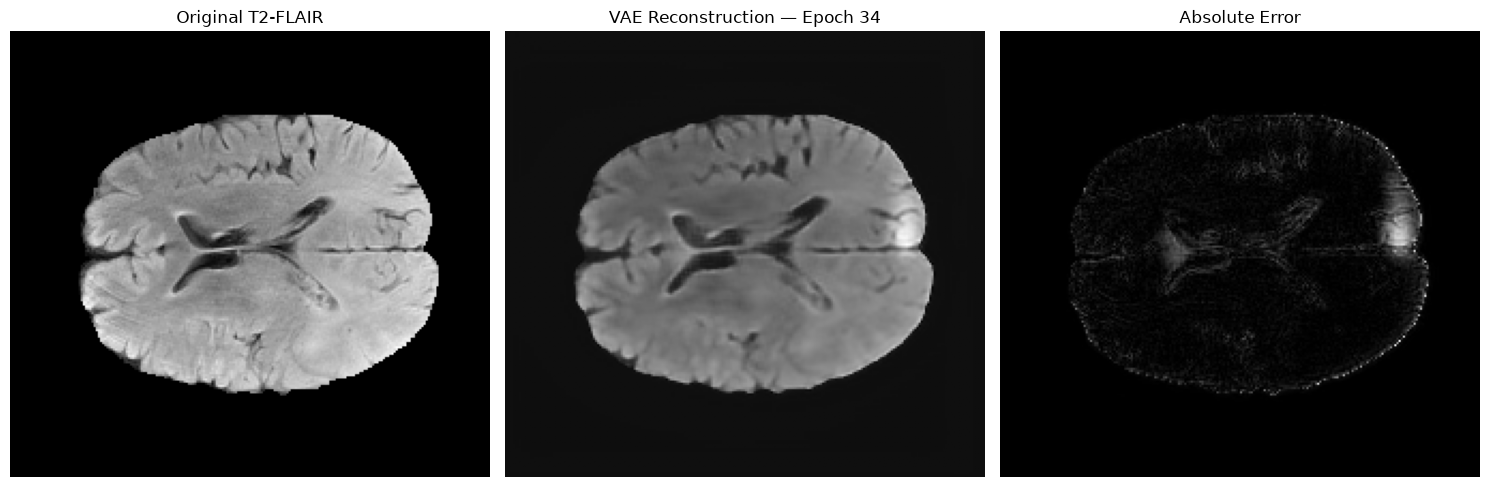

In [18]:
import matplotlib.pyplot as plt

# ============================================================
# VAE Epoch 34 — Visual comparison
# Original vs Reconstruction vs Absolute Error
# ============================================================

original_np = (
    original[0, 0]
    .detach()
    .float()
    .cpu()
    .numpy()
)

recon_np = (
    reconstruction[0, 0]
    .detach()
    .float()
    .cpu()
    .numpy()
)

error_np = np.abs(
    original_np
    - recon_np
)

# Use middle axial slice
axial_idx = (
    original_np.shape[2]
    // 2
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Original
axes[0].imshow(
    original_np[:, :, axial_idx],
    cmap="gray"
)

axes[0].set_title(
    "Original T2-FLAIR"
)

axes[0].axis(
    "off"
)

# Reconstruction
axes[1].imshow(
    recon_np[:, :, axial_idx],
    cmap="gray"
)

axes[1].set_title(
    "VAE Reconstruction — Epoch 34"
)

axes[1].axis(
    "off"
)

# Absolute error
axes[2].imshow(
    error_np[:, :, axial_idx],
    cmap="gray"
)

axes[2].set_title(
    "Absolute Error"
)

axes[2].axis(
    "off"
)

plt.tight_layout()
plt.show()